# Graficas de Prueba

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import FunctionTransformer

## Cargar dataset

In [2]:
df_customer = pd.read_csv("../data/processed/customer_features.csv", index_col="CustomerID")

print(df_customer.shape)
df_customer.head()

(5876, 10)


,Pais Principal,Paises Distintos,Permanencia,Compras,Canasta_Prom,Ticket_Prom,Precio_Prom,Precio_Max,Productos Distintos,Pct_Devoluciones
CustomerID,,,,,,,,,,
12347.0,Iceland,1,403.0,8,370.875,615.19125,1.658756,12.75,126,0.00
12348.0,Finland,1,364.0,5,542.800,403.88000,0.744068,40.00,25,0.00
12349.0,Italy,1,572.0,4,406.000,1107.17250,2.727026,300.00,138,0.25
12350.0,Norway,1,1.0,1,197.000,334.40000,1.697462,40.00,17,0.00
12351.0,Unspecified,1,1.0,1,261.000,300.93000,1.152989,12.75,21,0.00


### Transformacion log-normal (misma que en 01_eda)

In [3]:
df_customer_transformed = df_customer.copy()
transformers = dict()

cols_log_normal = [
    "Compras",
    "Canasta_Prom", "Ticket_Prom", "Precio_Prom", "Precio_Max",
    "Productos Distintos"
]
for col in cols_log_normal:
    transformer = FunctionTransformer(func=np.log1p, inverse_func=np.expm1, validate=True)
    transformer.fit(df_customer_transformed[[col]].to_numpy())

    transformers[col] = transformer

for col in cols_log_normal:
    df_customer_transformed[col] = transformers[col].transform(df_customer_transformed[[col]].to_numpy())

df_customer_transformed.describe()

,Paises Distintos,Permanencia,Compras,Canasta_Prom,Ticket_Prom,Precio_Prom,Precio_Max,Productos Distintos,Pct_Devoluciones
count,5876.000000,5876.000000,5876.000000,5876.000000,5876.000000,5876.000000,5876.000000,5876.000000,5876.000000
mean,1.002212,274.287270,1.549355,4.999872,5.621071,1.090667,2.686656,3.760129,0.192371
std,0.046988,258.997643,0.809555,0.921822,0.732573,0.465508,0.883648,1.219075,0.334928
min,1.000000,1.000000,0.693147,0.693147,0.000000,0.000000,0.000000,0.693147,0.000000
25%,1.000000,1.000000,0.693147,4.530256,5.189364,0.887146,2.251292,2.995732,0.000000
50%,1.000000,221.500000,1.386294,5.049856,5.641640,1.040241,2.621039,3.828641,0.000000
75%,1.000000,513.000000,2.079442,5.556828,6.032868,1.208729,2.887590,4.644391,0.277778
max,2.000000,739.000000,5.988961,11.375593,9.605470,9.301506,9.301506,7.844241,4.000000


## Boxplots de distribuciones (variables numericas)

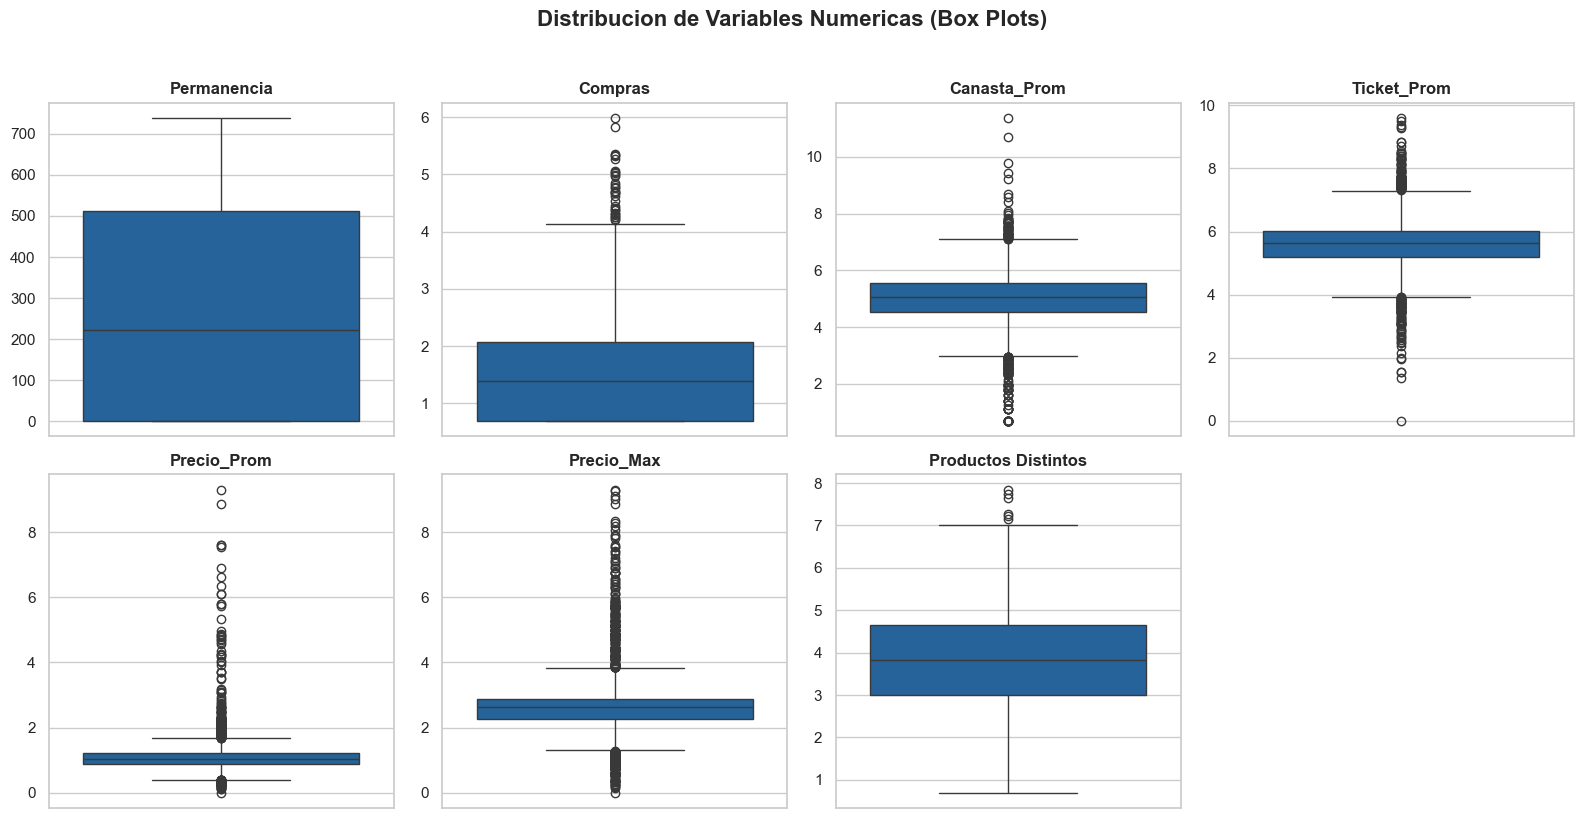

In [ ]:
cols_boxplot = [
    "Permanencia",
    "Compras",
    "Canasta_Prom", "Ticket_Prom", "Precio_Prom", "Precio_Max",
    "Productos Distintos"
]

n_cols = 3
n_rows = int(np.ceil(len(cols_boxplot) / n_cols))

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = axes.flatten()

fig.suptitle(
    "Distribucion de Variables Numericas (Box Plots)",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)

for ax, col in zip(axes, cols_boxplot):
    sns.boxplot(y=df_customer_transformed[col], ax=ax, color="#1164ad")
    ax.set_title(col, fontweight="bold")
    ax.set_ylabel("")

for ax in axes[len(cols_boxplot):]:
    ax.axis("off")

plt.tight_layout()
plt.show()
sns.reset_defaults()